# Take-Home 1: Data Analysis

**QSS 20: Modern Statistical Computing | Dartmouth College | Spring 2026**

this take-home tests your ability to work with a real-world dataset using the Pandas skills covered in class. You have the weekend to complete it (**due Sunday night 11:59 PM EST**). 

Please see the **take-home packet** for full logistics, context, and grading details.

**Dataset:** Cook County felony sentencing data (`sentencing_asof0405.csv`)

**Total points:** 65

---
## 0. Setup (0 points)

Load the necessary packages and the sentencing dataset.

**Note:** You may receive a warning about mixed data types upon import; feel free to ignore it.

In [ ]:
# Load packages
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
# Load the sentencing dataset
df = pd.read_csv("sentencing_asof0405.csv")

/var/folders/b0/my22vpt52xj12fkj2230c4lm0000gn/T/ipykernel_64844/1069847135.py:2: DtypeWarning: Columns (0: DISPOSITION_CHARGED_CHAPTER, 1: DISPOSITION_CHARGED_ACT, 2: DISPOSITION_CHARGED_AOIC, 3: COMMITMENT_TERM) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("sentencing_asof0405.csv")


---
## 1. Data Inspection & Understanding (15 points)

### 1a. Print the dimensions of the dataset and the first few rows.

In [4]:
# Your code here
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 248146 entries, 0 to 248145
Data columns (total 41 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   CASE_ID                            248146 non-null  int64  
 1   CASE_PARTICIPANT_ID                248146 non-null  int64  
 2   RECEIVED_DATE                      248146 non-null  str    
 3   OFFENSE_CATEGORY                   248146 non-null  str    
 4   PRIMARY_CHARGE_FLAG                248146 non-null  bool   
 5   CHARGE_ID                          248146 non-null  int64  
 6   CHARGE_VERSION_ID                  248146 non-null  int64  
 7   DISPOSITION_CHARGED_OFFENSE_TITLE  248146 non-null  str    
 8   CHARGE_COUNT                       248146 non-null  int64  
 9   DISPOSITION_DATE                   248146 non-null  str    
 10  DISPOSITION_CHARGED_CHAPTER        248146 non-null  object 
 11  DISPOSITION_CHARGED_ACT            242771 non-null

In [ ]:
df.head()

,CASE_ID,CASE_PARTICIPANT_ID,RECEIVED_DATE,OFFENSE_CATEGORY,PRIMARY_CHARGE_FLAG,CHARGE_ID,CHARGE_VERSION_ID,DISPOSITION_CHARGED_OFFENSE_TITLE,CHARGE_COUNT,DISPOSITION_DATE,...,INCIDENT_CITY,INCIDENT_BEGIN_DATE,INCIDENT_END_DATE,LAW_ENFORCEMENT_AGENCY,LAW_ENFORCEMENT_UNIT,ARREST_DATE,FELONY_REVIEW_DATE,FELONY_REVIEW_RESULT,ARRAIGNMENT_DATE,UPDATED_OFFENSE_CATEGORY
0,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50510112469,116304211997,FIRST DEGREE MURDER,2,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
1,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50510213021,98265074680,HOME INVASION,14,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
2,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50516447217,131972895911,FIRST DEGREE MURDER,4,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
3,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50516497493,131966356472,FIRST DEGREE MURDER,5,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide
4,149765331439,175691153649,8/15/1984 12:00:00 AM,PROMIS Conversion,False,50516648320,98059642859,HOME INVASION,13,12/17/2014 12:00:00 AM,...,NaN,8/9/1984 12:00:00 AM,NaN,CHICAGO POLICE DEPT,NaN,8/15/1984 12:00:00 AM,08/15/1984 12:00:00 AM,Charge(S) Approved,9/21/1984 12:00:00 AM,Homicide


### 1b. How many unique cases (`CASE_ID`), participants (`CASE_PARTICIPANT_ID`), and charges (`CHARGE_ID`) are there? What does this tell you about the unit of analysis?

In [ ]:
# Your code here
len(df["CASE_ID"].unique())

197519

In [ ]:
len(df["CASE_PARTICIPANT_ID"].unique())

211977

In [ ]:
len(df["CHARGE_ID"].unique())

229015

There are more participants than cases and more charges than participants. This indicates that a case can involve multiple participants, and each participant can have multiple charges. Therefore, the unit of analysis (each row) is most likely an individual charge associated with a single participant within a single case. The diagram below illustrates this hierarchy. Each row in the dataset corresponds to one case–participant–charge combination.

```text
Case 1
├── Participant 1
│   ├── Charge 1
│   └── Charge 2
└── Participant 2
    └── Charge 3
Case 2
├── Participant 1
│   ├── Charge 1
│   └── Charge 2
└── Participant 2
    └── Charge 3
```

### 1c. In 2-3 sentences, describe what each row in this dataset represents and why the counts above differ.

As above, each row in the dataset represents a one case-participant-charge combination, i.e. one charge against one participant in one case. The counts differ because cases can have multiple charges and participants, and participants can have multiple charges and, potentially, cases. So, there is a fair amount of overlap, which results in fewer unique case IDs and more unique charges and participants.


---
## 2. Data Cleaning (20 points)

### 2a. The variable `RACE` has many categories. Create a simplified variable called `race_clean` that identifies defendants as "Black", "White", "Hispanic", or "Other".

There is overlap here. I wasn't sure if you wanted me to include hispanic white people in hispanic category or the white category, for example. I include them in hispanic as that is my understanding of how they are most likely to identify.

In [ ]:
df["race_clean"] = (
    df["RACE"]
    .map(
        {
            "White": "White",
            "Black": "Black",
            "White [Hispanic or Latino]": "Hispanic",
            "HISPANIC": "Hispanic",
        }
    )  # for any race not listed, map will return NaN
    .fillna("Other")  # I fill that Nan with Other
)

### 2b. Print the value counts of the original `RACE` variable and the cleaned `race_clean` variable to validate your work.

In [ ]:
df["RACE"].value_counts()

RACE
Black                               164423
White [Hispanic or Latino]           37880
White                                35361
HISPANIC                              5941
Asian                                 1453
White/Black [Hispanic or Latino]      1238
Unknown                                358
American Indian                        125
ASIAN                                   65
Biracial                                35
Name: count, dtype: int64

In [ ]:
df["race_clean"].value_counts()

race_clean
Black       164423
Hispanic     43821
White        35361
Other         4541
Name: count, dtype: int64

### 2c. Subset the data to only primary charges (`PRIMARY_CHARGE_FLAG` is True) so each defendant-case appears once. Print how many rows you started with and how many remain after subsetting.

In [ ]:
# Your code here
len(df)

248146

In [ ]:
df = df[df["PRIMARY_CHARGE_FLAG"]]
len(df)

180625

---
## 3. Descriptive Analysis (30 points)

Use your cleaned, primary-charge-only data for this section.

### 3a. Compute the incarceration rate by race.

According to the codebook, incarceration is indicated by `COMMITMENT_TYPE == "Illinois Department of Corrections"`. Present these rates in a table.

In [ ]:
incarceration_rates = (
    df.groupby("race_clean")
    .agg(
        incarceration_rate=(
            "COMMITMENT_TYPE",
            lambda x: (
                x == "Illinois Department of Corrections"
            ).mean(),  # Bools evaluate to 1 (true) or 0 (false). Taking the mean gives the proportion incarcerated.
        )
    )
    .sort_values("incarceration_rate", ascending=False)  # sort for clarity in chart
)
incarceration_rates

,incarceration_rate
race_clean,
Black,0.554872
Hispanic,0.377726
White,0.369879
Other,0.341591


### 3b. Create a visualization (your choice of chart type) that clearly communicates the comparison of incarceration rates across racial groups.

Make sure your visualization has:
- A descriptive title
- Labeled axes
- A legend (if applicable)

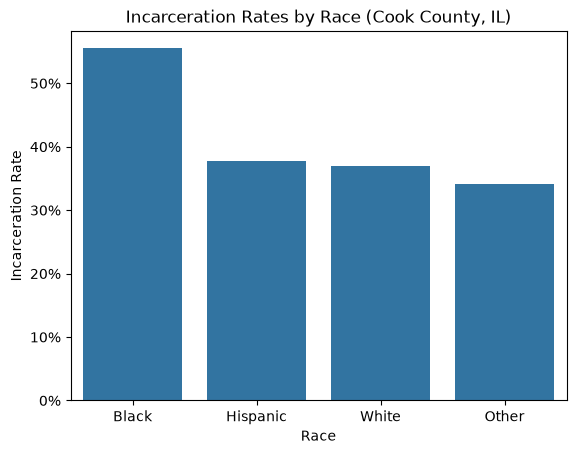

In [ ]:
from matplotlib.ticker import PercentFormatter  # for percent formatting y-axis

ax = sns.barplot(data=incarceration_rates, x="race_clean", y="incarceration_rate")
ax.yaxis.set_major_formatter(
    PercentFormatter(1)
)  # this sets the y-axis formatter to percent which is cleaner

plt.title("Incarceration Rates by Race (Cook County, IL)")
plt.xlabel("Race")
plt.ylabel("Incarceration Rate")

plt.savefig("Writeup/barplot.png")